# Demographic and Procedural Bias in ML Models Trained on Surgical Outcome Data

**Research Hypotheses:**
- **H1:** The baseline model will show statistically significant performance disparity across demographic groups.
- **H2:** Applying bias mitigation techniques will reduce disparity.
- **H3:** There will be a measurable trade-off between fairness and predictive accuracy.

**Mitigation Techniques:**
1. **Pre-processing:** Reweighing 
2. **In-processing:** Exponentiated Gradient 
3. **Post-processing:** Threshold Optimisation

**Sensitive Attributes:** race_group, gender, insurance_group, age_group

## 1. Setup & Imports

In [ ]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve
)
from sklearn.calibration import calibration_curve
from xgboost import XGBClassifier

from fairlearn.metrics import (
    MetricFrame, demographic_parity_difference,
    equalized_odds_difference, true_positive_rate, false_positive_rate
)
from fairlearn.postprocessing import ThresholdOptimizer
from fairlearn.reductions import ExponentiatedGradient, DemographicParity, EqualizedOdds

warnings.filterwarnings('ignore')

os.makedirs("results", exist_ok=True)
os.makedirs("figures", exist_ok=True)

SEED = 42
np.random.seed(SEED)

TARGET = "hospital_expire_flag"
PROTECTED_ATTRS = ["gender", "race_group", "insurance_group", "age_group"]
MAIN_ATTR = "race_group" 

print("All imports are successful.")

All imports are successful.


## 2. Data Loading & Preprocessing

In [64]:
cohort = pd.read_csv("cohort.csv")

print("Top missing values (%):\n")
print((cohort.isna().mean() * 100).sort_values(ascending=False).head(10))
print(f"\nDuplicate count: {cohort.duplicated().sum()}")
print(f"Original shape: {cohort.shape}")

Top missing values (%):

lab_lactate            47.617655
lab_ph                 45.921148
vital_map               8.105362
vital_dbp               8.089967
vital_sbp               8.080730
vital_temperature_f     6.027064
lab_hemoglobin          3.737857
lab_wbc                 3.724002
lab_platelets           3.702449
lab_glucose             3.463830
dtype: float64

Duplicate count: 0
Original shape: (64957, 47)


In [65]:
# Drop useless columns like ID and the other ones mentioned below
cohort = cohort.drop(columns=[
    "subject_id", "hadm_id", "stay_id", "marital_status", "long_icu_stay", "los_hospital_hrs", "los", "dod_known", "lab_lactate", "lab_ph"                 
])

# Standardise missing values
cohort = cohort.replace(["", "nan", "None", "unknown", "Unknown"], np.nan)

# Finding the median for numeric columns 
num_cols = cohort.select_dtypes(include="number").columns.tolist()
numeric_impute_cols = [c for c in num_cols if c != TARGET]
for col in numeric_impute_cols:
    cohort[col] = cohort[col].fillna(cohort[col].median())

# Drop rows with missing protected attributes
cohort = cohort.dropna(subset=["race_group", "insurance_group"])

# Create age groups
cohort["age_group"] = pd.cut(
    cohort["anchor_age"],
    bins=[0, 40, 60, 200],
    labels=["Under 40", "40 to 60", "Over 60"]
)
cohort = cohort.drop(columns=["anchor_age"])

print(f"\nFinal shape: {cohort.shape}")
print(f"Mortality rate: {cohort[TARGET].mean():.2%}")
print(f"\nRemaining missing values:\n{cohort.isna().sum().sort_values(ascending=False).head(10)}")


Final shape: (64957, 37)
Mortality rate: 10.10%

Remaining missing values:
hospital_expire_flag    0
lab_hemoglobin          0
lab_potassium           0
lab_sodium              0
lab_urea_nitrogen       0
lab_wbc                 0
vital_dbp               0
vital_gcs_eye           0
vital_gcs_motor         0
vital_gcs_verbal        0
dtype: int64


### 2.1 Demographic Distribution Analysis

In [66]:
# Examine demographic distributions and mortality rates per group
for attr in PROTECTED_ATTRS:
    print(f"\n{'='*60}")
    print(f"Distribution of '{attr}':")
    counts = cohort[attr].value_counts()
    print(counts)
    print(f"\nMortality rate by '{attr}':")
    mort_rates = cohort.groupby(attr)[TARGET].mean()
    print(mort_rates.round(4))


Distribution of 'gender':
gender
0    35670
1    29287
Name: count, dtype: int64

Mortality rate by 'gender':
gender
0    0.0992
1    0.1032
Name: hospital_expire_flag, dtype: float64

Distribution of 'race_group':
race_group
WHITE         53124
BLACK          7821
OTHER          2828
ASIAN          1005
INDIGENOUS      179
Name: count, dtype: int64

Mortality rate by 'race_group':
race_group
ASIAN         0.1274
BLACK         0.0967
INDIGENOUS    0.1117
OTHER         0.0990
WHITE         0.1012
Name: hospital_expire_flag, dtype: float64

Distribution of 'insurance_group':
insurance_group
government    45472
private       19485
Name: count, dtype: int64

Mortality rate by 'insurance_group':
insurance_group
government    0.1136
private       0.0716
Name: hospital_expire_flag, dtype: float64

Distribution of 'age_group':
age_group
Over 60     39432
40 to 60    19053
Under 40     6472
Name: count, dtype: int64

Mortality rate by 'age_group':
age_group
Under 40    0.0399
40 to 60    0.074

## 3. Feature Engineering & Train/Test Split

In [67]:
# Store protected attributes before encoding
protected_df = cohort[PROTECTED_ATTRS].copy()

# Encode categorical features
cohort_encoded = pd.get_dummies(
    cohort,
    columns=["race_group", "insurance_group", "age_group"],
    drop_first=False
)

feature_cols = [c for c in cohort_encoded.columns if c != TARGET]
X = cohort_encoded[feature_cols]
y = cohort[TARGET]

print(f"X shape: {X.shape}")
print(f"Features: {feature_cols}")
print(f"Class balance — 0: {(y==0).sum()}  1: {(y==1).sum()}")

X shape: (64957, 43)
Features: ['is_emergency', 'gender', 'cm_aki', 'cm_alcohol', 'cm_cad', 'cm_ckd', 'cm_copd', 'cm_diabetes', 'cm_heart_failure', 'cm_hypertension', 'lab_anion_gap', 'lab_bicarbonate', 'lab_chloride', 'lab_creatinine', 'lab_glucose', 'lab_hematocrit', 'lab_hemoglobin', 'lab_platelets', 'lab_potassium', 'lab_sodium', 'lab_urea_nitrogen', 'lab_wbc', 'vital_dbp', 'vital_gcs_eye', 'vital_gcs_motor', 'vital_gcs_verbal', 'vital_heart_rate', 'vital_map', 'vital_resp_rate', 'vital_sbp', 'vital_spo2', 'vital_temperature_f', 'gcs_total', 'race_group_ASIAN', 'race_group_BLACK', 'race_group_INDIGENOUS', 'race_group_OTHER', 'race_group_WHITE', 'insurance_group_government', 'insurance_group_private', 'age_group_Under 40', 'age_group_40 to 60', 'age_group_Over 60']
Class balance — 0: 58396  1: 6561


In [ ]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# Align protected attributes to splits
sens_test = protected_df.loc[X_test.index]
sens_train = protected_df.loc[X_train.index]
s_test = sens_test[MAIN_ATTR]
s_train = sens_train[MAIN_ATTR]

# Standard scaling 
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=feature_cols, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_cols, index=X_test.index
)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Train mortality rate: {y_train.mean():.2%}")
print(f"Test mortality rate:  {y_test.mean():.2%}")

X_train: (51965, 43), X_test: (12992, 43)
Train mortality rate: 10.10%
Test mortality rate:  10.10%


## 4. Evaluation Framework

Helper functions for computing:
- **Standard metrics:** Accuracy, Precision, Recall, F1, ROC-AUC, FPR, FNR
- **Fairness metrics:** Demographic Parity Difference, Equal Opportunity Difference, Equalised Odds Difference, FPR Gap, FNR Gap, Calibration Difference
- **Statistical testing:** Bootstrap confidence intervals for fairness metrics

In [69]:
def get_standard_metrics(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "accuracy":  round(accuracy_score(y_true, y_pred), 4),
        "precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "recall":    round(recall_score(y_true, y_pred, zero_division=0), 4),
        "f1":        round(f1_score(y_true, y_pred, zero_division=0), 4),
        "roc_auc":   round(roc_auc_score(y_true, y_prob), 4),
        "fpr":       round(fp / (fp + tn) if (fp + tn) > 0 else 0, 4),
        "fnr":       round(fn / (fn + tp) if (fn + tp) > 0 else 0, 4),
    }


def get_fairness_metrics(y_true, y_pred, sensitive):
    dpd = demographic_parity_difference(y_true, y_pred, sensitive_features=sensitive)
    eod = equalized_odds_difference(y_true, y_pred, sensitive_features=sensitive)
    
    mf = MetricFrame(
        metrics={
            "tpr": true_positive_rate,
            "fpr": false_positive_rate,
        },
        y_true=y_true, y_pred=y_pred,
        sensitive_features=sensitive
    )
    tprs = mf.by_group["tpr"]
    fprs = mf.by_group["fpr"]
    equal_opp = float(tprs.max() - tprs.min())
    fpr_gap = float(fprs.max() - fprs.min())
    fnr_gap = float((1 - tprs).max() - (1 - tprs).min())  # FNR = 1 - TPR
    
    return {
        "dem_parity_diff": round(abs(dpd), 4),
        "equal_opp_diff":  round(equal_opp, 4),
        "equalized_odds":  round(abs(eod), 4),
        "fpr_gap":         round(fpr_gap, 4),
        "fnr_gap":         round(fnr_gap, 4),
    }


def evaluate_model(method, model_name, y_true, y_pred, y_prob, sensitive):
    row = {"method": method, "model": model_name}
    row.update(get_standard_metrics(y_true, y_pred, y_prob))
    row.update(get_fairness_metrics(y_true, y_pred, sensitive))
    return row


def evaluate_model_all_attrs(method, model_name, y_true, y_pred, y_prob, sens_df):
    # Evaluate fairness across all protected attributes.
    results = []
    for attr in PROTECTED_ATTRS:
        row = {"method": method, "model": model_name, "sensitive_attr": attr}
        row.update(get_standard_metrics(y_true, y_pred, y_prob))
        row.update(get_fairness_metrics(y_true, y_pred, sens_df[attr]))
        results.append(row)
    return results


def bootstrap_fairness_ci(y_true, y_pred, sensitive, n_boot=1000, alpha=0.05):
    # Compute bootstrap confidence intervals for fairness metrics.
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    sensitive = np.array(sensitive)
    n = len(y_true)
    
    boot_dpd = []
    boot_eod = []
    boot_eo = []
    
    for _ in range(n_boot):
        idx = np.random.choice(n, size=n, replace=True)
        yt_b, yp_b, s_b = y_true[idx], y_pred[idx], sensitive[idx]
        
        # Skip if any group has no positive or no negative samples
        try:
            dpd = abs(demographic_parity_difference(yt_b, yp_b, sensitive_features=s_b))
            eod_val = abs(equalized_odds_difference(yt_b, yp_b, sensitive_features=s_b))
            mf = MetricFrame(
                metrics={"tpr": true_positive_rate},
                y_true=yt_b, y_pred=yp_b, sensitive_features=s_b
            )
            tprs = mf.by_group["tpr"]
            eo = float(tprs.max() - tprs.min())
            boot_dpd.append(dpd)
            boot_eod.append(eod_val)
            boot_eo.append(eo)
        except Exception:
            continue
    
    lo = alpha / 2 * 100
    hi = (1 - alpha / 2) * 100
    
    return {
        "dem_parity_diff": (np.median(boot_dpd), np.percentile(boot_dpd, lo), np.percentile(boot_dpd, hi)),
        "equal_opp_diff":  (np.median(boot_eo), np.percentile(boot_eo, lo), np.percentile(boot_eo, hi)),
        "equalized_odds":  (np.median(boot_eod), np.percentile(boot_eod, lo), np.percentile(boot_eod, hi)),
    }


print("Evaluation framework is ready.")

Evaluation framework is ready.


## 5. Baseline Model Training

In [70]:
# Logistic Regression 
lr_base = LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced")
lr_base.fit(X_train_scaled, y_train)
lr_pred = lr_base.predict(X_test_scaled)
lr_prob = lr_base.predict_proba(X_test_scaled)[:, 1]

# Random Forest 
rf_base = RandomForestClassifier(
    n_estimators=100, random_state=SEED,
    class_weight="balanced_subsample", min_samples_leaf=5
)
rf_base.fit(X_train, y_train)
rf_pred = rf_base.predict(X_test)
rf_prob = rf_base.predict_proba(X_test)[:, 1]

# XGBoost 
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
xgb_base = XGBClassifier(
    n_estimators=100, random_state=SEED,
    eval_metric="logloss", verbosity=0,
    scale_pos_weight=neg / pos
)
xgb_base.fit(X_train, y_train)
xgb_pred = xgb_base.predict(X_test)
xgb_prob = xgb_base.predict_proba(X_test)[:, 1]

print("Baseline models are trained.")

Baseline models are trained.


### 5.1 Baseline Evaluation 

In [71]:
all_results = []
all_results_multi = []  # Results across all sensitive attributes

for model_name, y_pred, y_prob in [
    ("LR",  lr_pred,  lr_prob),
    ("RF",  rf_pred,  rf_prob),
    ("XGB", xgb_pred, xgb_prob),
]:
    row = evaluate_model("Baseline", model_name, y_test, y_pred, y_prob, s_test)
    all_results.append(row)
    
    # Multi-attribute evaluation
    multi_rows = evaluate_model_all_attrs("Baseline", model_name, y_test, y_pred, y_prob, sens_test)
    all_results_multi.extend(multi_rows)
    
    print(f"\n=== Baseline {model_name} ===")
    for k, v in row.items():
        if k not in ("method", "model"):
            print(f"  {k:25s}: {v}")


=== Baseline LR ===
  accuracy                 : 0.7805
  precision                : 0.284
  recall                   : 0.7713
  f1                       : 0.4151
  roc_auc                  : 0.8499
  fpr                      : 0.2185
  fnr                      : 0.2287
  dem_parity_diff          : 0.2357
  equal_opp_diff           : 0.3393
  equalized_odds           : 0.3393
  fpr_gap                  : 0.2483
  fnr_gap                  : 0.3393

=== Baseline RF ===
  accuracy                 : 0.9117
  precision                : 0.5783
  recall                   : 0.4642
  f1                       : 0.515
  roc_auc                  : 0.8849
  fpr                      : 0.038
  fnr                      : 0.5358
  dem_parity_diff          : 0.0479
  equal_opp_diff           : 0.1571
  equalized_odds           : 0.1571
  fpr_gap                  : 0.0325
  fnr_gap                  : 0.1571

=== Baseline XGB ===
  accuracy                 : 0.8583
  precision                : 0.3813
  r

### 5.2 Statistical Significance Testing (Bootstrap CIs for H1)

In [72]:
print("Bootstrap 95% confidence intervals for baseline fairness metrics")
print("(Testing H1: statistically significant performance disparity)\n")

for model_name, y_pred in [("LR", lr_pred), ("RF", rf_pred), ("XGB", xgb_pred)]:
    ci = bootstrap_fairness_ci(y_test, y_pred, s_test, n_boot=1000)
    print(f"=== {model_name} ===")
    for metric, (point, lo, hi) in ci.items():
        sig = "*" if lo > 0.0 else ""  # Significant if CI doesn't include 0
        print(f"  {metric:25s}: {point:.4f}  [{lo:.4f}, {hi:.4f}] {sig}")
    print()

Bootstrap 95% confidence intervals for baseline fairness metrics
(Testing H1: statistically significant performance disparity)

=== LR ===
  dem_parity_diff          : 0.2379  [0.1156, 0.4093] *
  equal_opp_diff           : 0.3552  [0.2453, 1.0000] *
  equalized_odds           : 0.3667  [0.2531, 1.0000] *

=== RF ===
  dem_parity_diff          : 0.0626  [0.0229, 0.1229] *
  equal_opp_diff           : 0.5000  [0.1089, 0.7500] *
  equalized_odds           : 0.5000  [0.1089, 0.7500] *

=== XGB ===
  dem_parity_diff          : 0.0761  [0.0247, 0.2199] *
  equal_opp_diff           : 0.4734  [0.3846, 0.7679] *
  equalized_odds           : 0.4734  [0.3846, 0.7679] *



## 6. Group-Level Analysis (FPR / FNR / AUC per Demographic Group)

In [73]:
# Build test dataframe with predictions
test_df = X_test.copy()
test_df["y_true"] = y_test.values
for attr in PROTECTED_ATTRS:
    test_df[attr] = sens_test[attr].values
test_df["lr_pred"] = lr_pred
test_df["lr_prob"] = lr_prob
test_df["rf_pred"] = rf_pred
test_df["rf_prob"] = rf_prob
test_df["xgb_pred"] = xgb_pred
test_df["xgb_prob"] = xgb_prob

print(f"test_df shape: {test_df.shape}")
test_df.head()

test_df shape: (12992, 53)


,is_emergency,gender,cm_aki,cm_alcohol,cm_cad,cm_ckd,cm_copd,cm_diabetes,cm_heart_failure,cm_hypertension,...,y_true,race_group,insurance_group,age_group,lr_pred,lr_prob,rf_pred,rf_prob,xgb_pred,xgb_prob
42699,0,0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,...,0,OTHER,private,Over 60,0,0.050002,0,0.033458,0,0.018531
28883,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,BLACK,private,Under 40,0,0.055801,0,0.000000,0,0.015142
8264,1,1,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,...,0,WHITE,government,Over 60,0,0.246459,0,0.239765,0,0.366948
54926,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0,ASIAN,government,Over 60,0,0.268103,0,0.052839,0,0.016605
16771,1,0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,0,WHITE,private,Over 60,1,0.924021,1,0.762091,1,0.928581


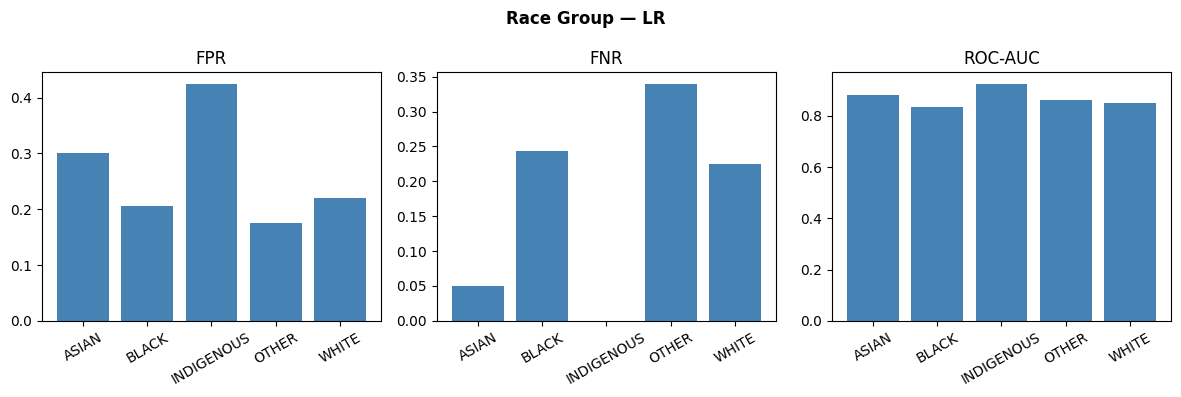

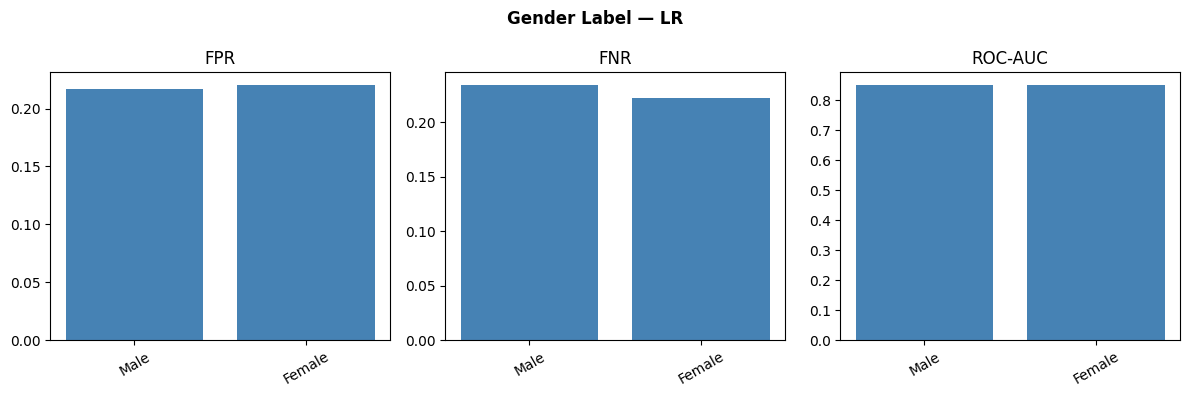

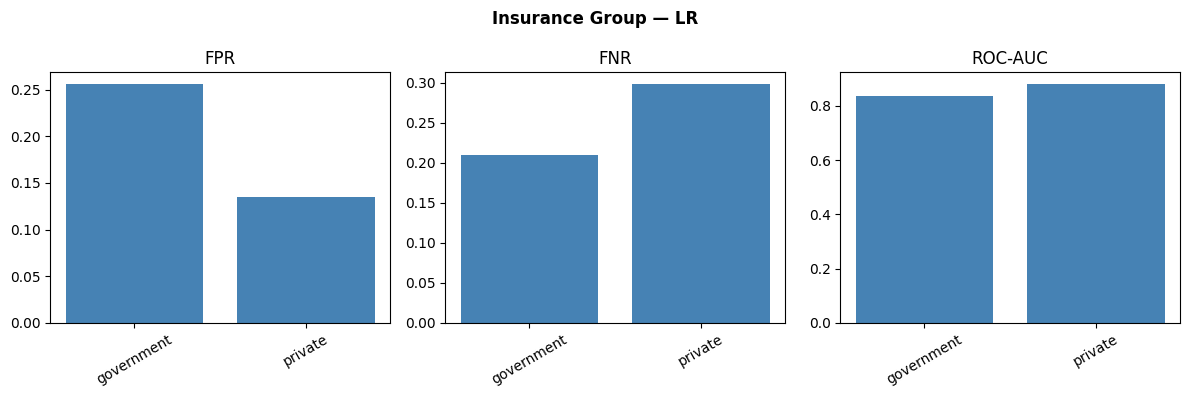

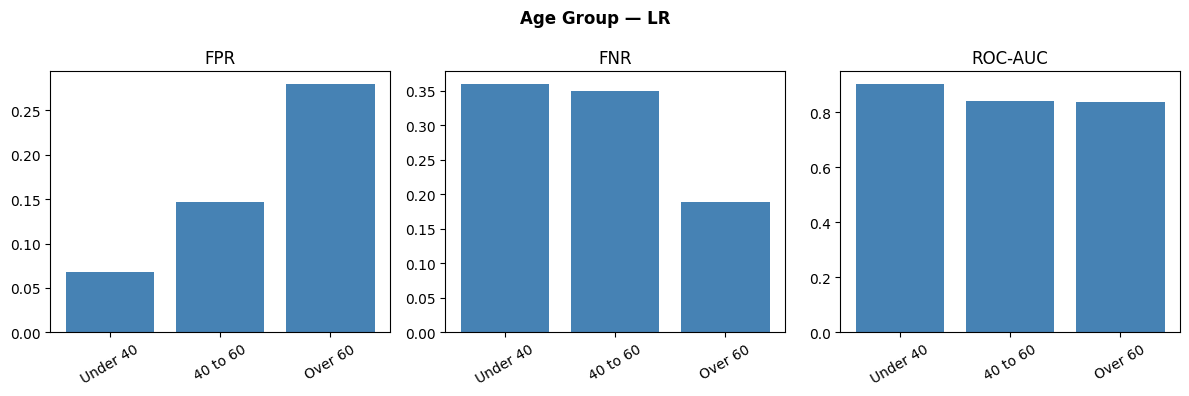

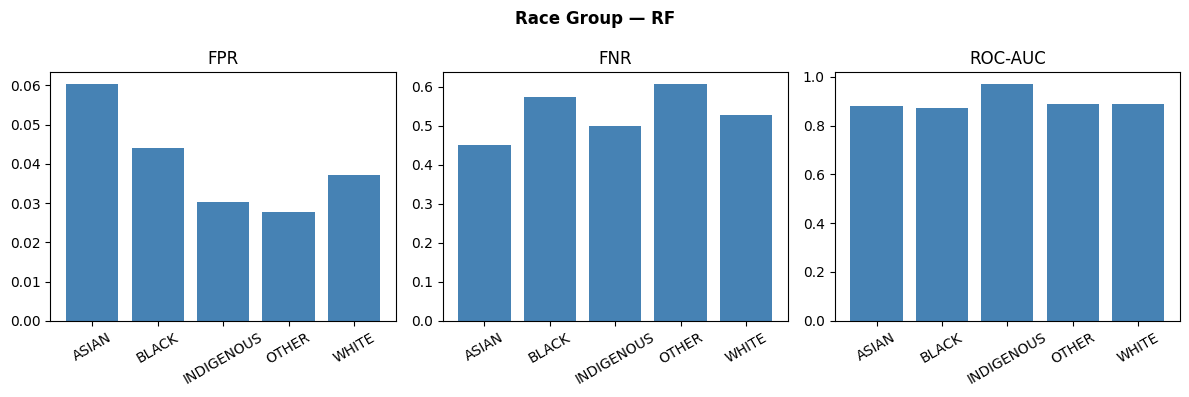

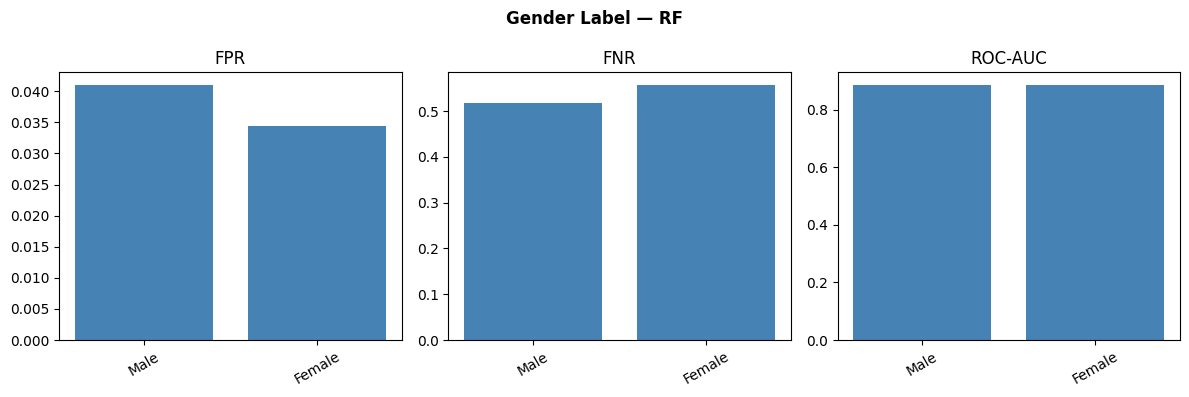

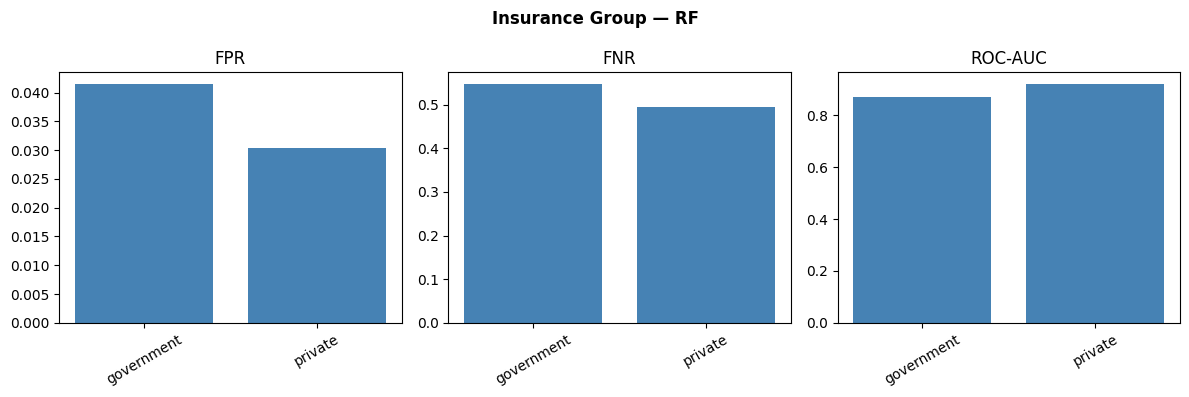

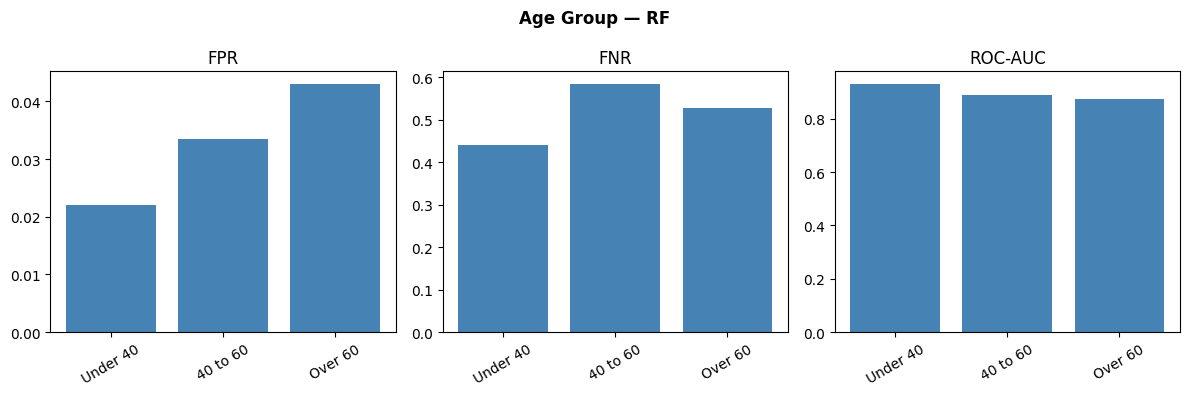

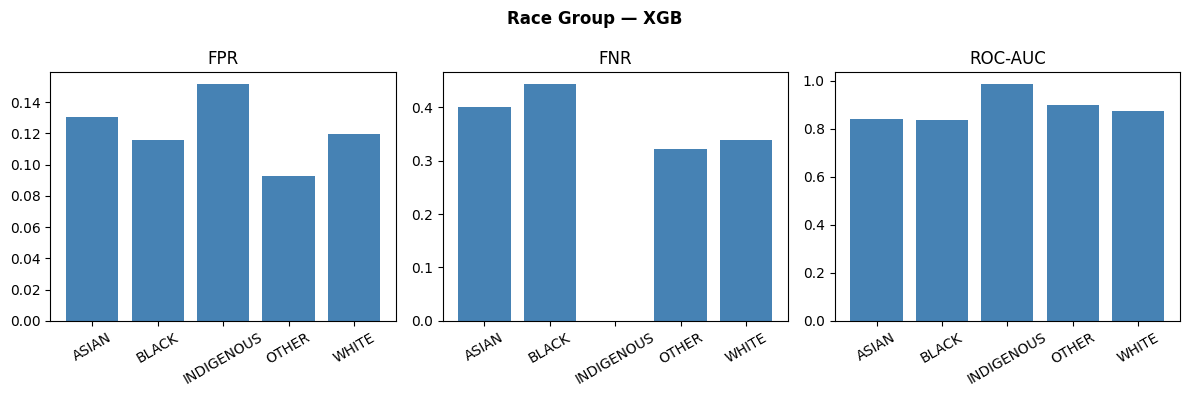

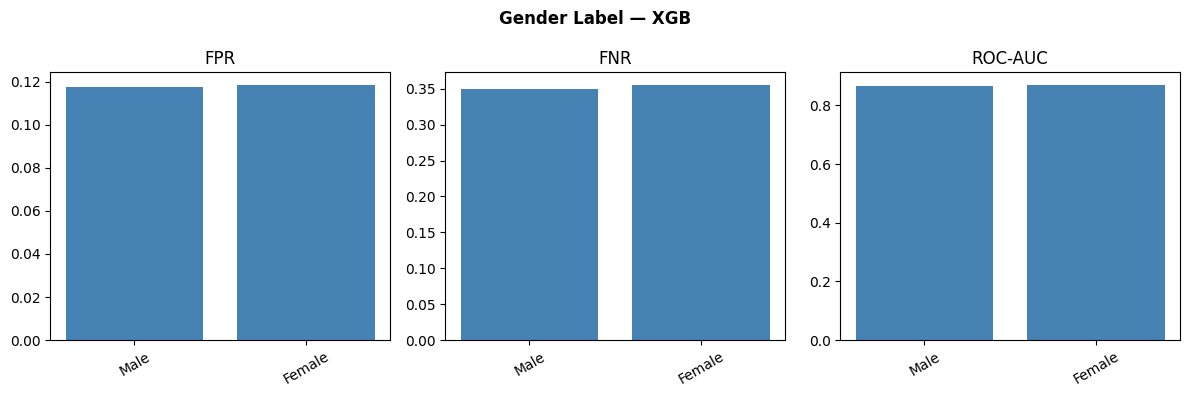

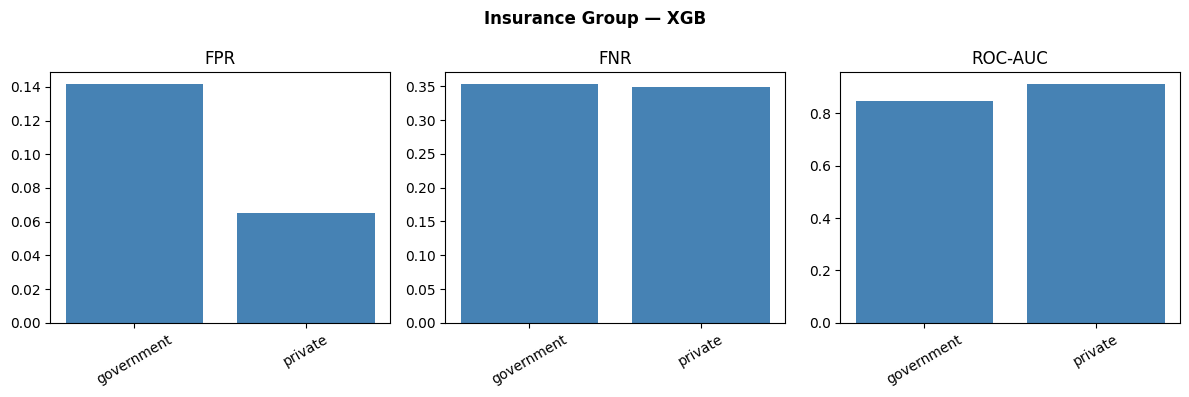

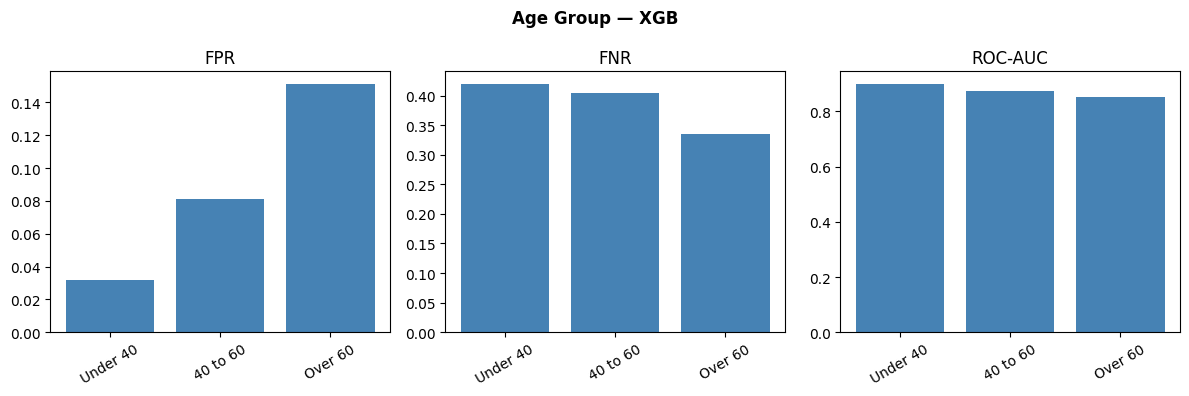

In [74]:
def plot_group_metrics(attr, labels, pred_col, prob_col, model_name):
    metrics = {"FPR": [], "FNR": [], "ROC-AUC": []}
    for group in labels:
        gdf = test_df[test_df[attr] == group]
        y_true = gdf["y_true"].values
        y_pred = gdf[pred_col].values
        y_prob = gdf[prob_col].values
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
        metrics["FPR"].append(fp / (fp + tn) if (fp + tn) > 0 else 0)
        metrics["FNR"].append(fn / (fn + tp) if (fn + tp) > 0 else 0)
        metrics["ROC-AUC"].append(
            roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan
        )

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    fig.suptitle(f"{attr.replace('_', ' ').title()} — {model_name}", fontweight="bold")
    for ax, (metric, vals) in zip(axes, metrics.items()):
        ax.bar([str(l) for l in labels], vals, color="steelblue")
        ax.set_title(metric)
        ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()
    plt.savefig(f"figures2/{attr}_{model_name}.png", dpi=150, bbox_inches="tight")
    plt.show()
    
# Plot for all models and all sensitive attributes
gender_label_map = {0: "Male", 1: "Female"}
test_df["gender_label"] = test_df["gender"].map(gender_label_map)

attr_labels = {
    "race_group":      ["ASIAN", "BLACK", "INDIGENOUS", "OTHER", "WHITE"],
    "gender_label":     ["Male", "Female"],
    "insurance_group":  ["government", "private"],
    "age_group":        ["Under 40", "40 to 60", "Over 60"],
}

for model_name, pred_col, prob_col in [
    ("LR", "lr_pred", "lr_prob"),
    ("RF", "rf_pred", "rf_prob"),
    ("XGB", "xgb_pred", "xgb_prob"),
]:
    for attr, labels in attr_labels.items():
        plot_group_metrics(attr, labels, pred_col, prob_col, model_name)

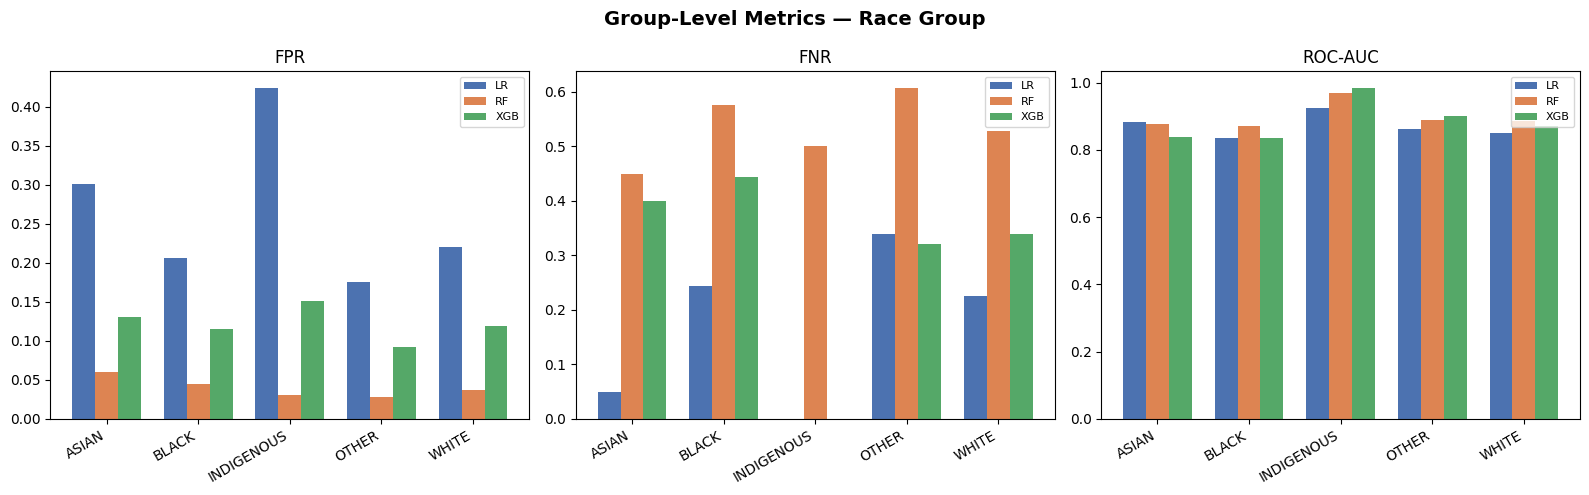

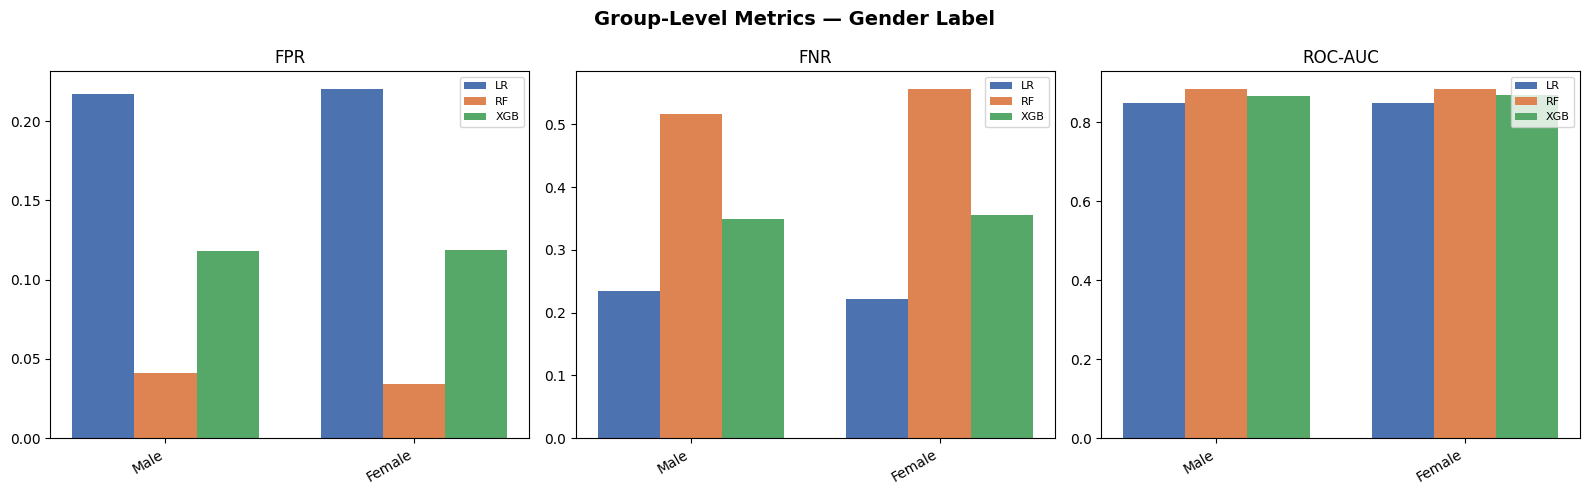

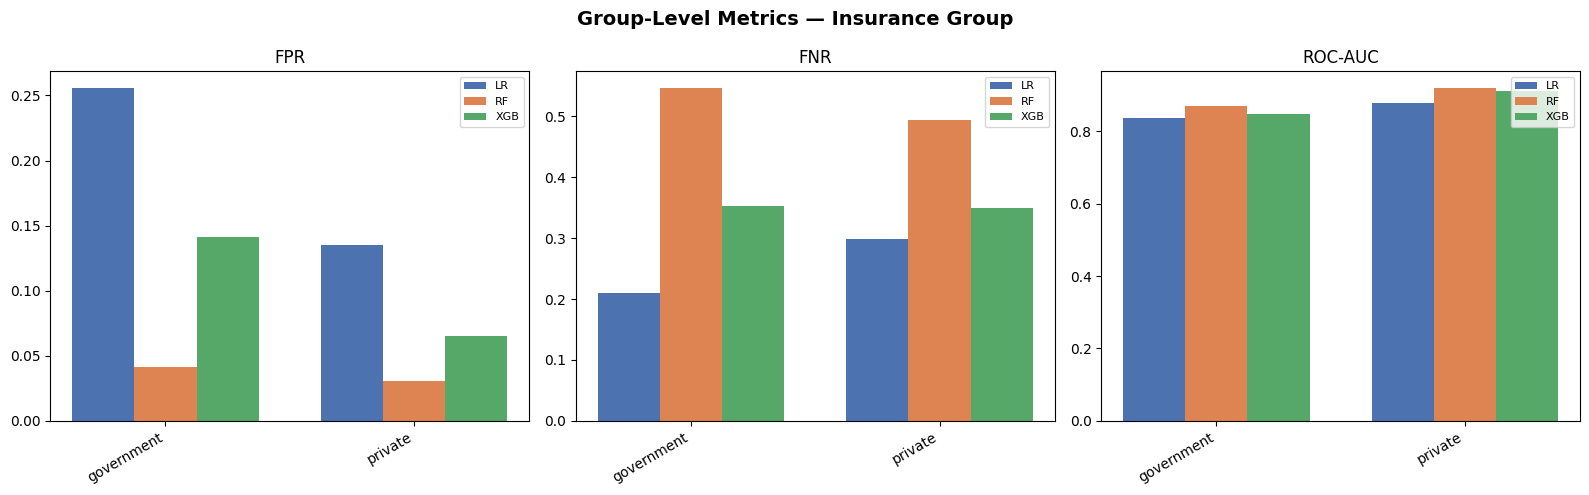

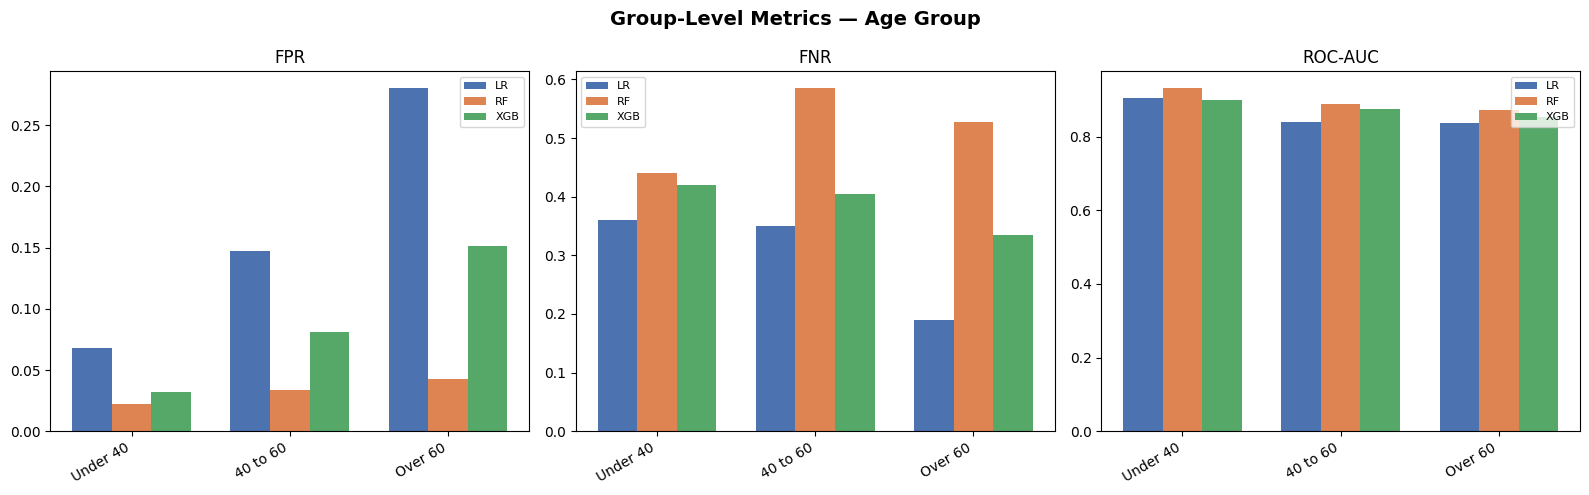

In [75]:
def plot_combined_group_metrics(attr, labels):
    model_configs = [
        ("LR", "lr_pred", "lr_prob", "#4C72B0"),
        ("RF", "rf_pred", "rf_prob", "#DD8452"),
        ("XGB", "xgb_pred", "xgb_prob", "#55A868"),
    ]
    metric_names = ["FPR", "FNR", "ROC-AUC"]
    all_metrics = {}

    for model_name, pred_col, prob_col, _ in model_configs:
        m = {"FPR": [], "FNR": [], "ROC-AUC": []}
        for group in labels:
            gdf = test_df[test_df[attr] == group]
            y_true = gdf["y_true"].values
            y_pred = gdf[pred_col].values
            y_prob = gdf[prob_col].values
            tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
            m["FPR"].append(fp / (fp + tn) if (fp + tn) > 0 else 0)
            m["FNR"].append(fn / (fn + tp) if (fn + tp) > 0 else 0)
            m["ROC-AUC"].append(
                roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan
            )
        all_metrics[model_name] = m

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f"Group-Level Metrics — {attr.replace('_', ' ').title()}", fontweight="bold", fontsize=14)

    str_labels = [str(l) for l in labels]
    x = np.arange(len(labels))
    width = 0.25

    for ax, metric in zip(axes, metric_names):
        for i, (model_name, _, _, colour) in enumerate(model_configs):
            vals = all_metrics[model_name][metric]
            ax.bar(x + i * width, vals, width, label=model_name, color=colour)
        ax.set_title(metric)
        ax.set_xticks(x + width)
        ax.set_xticklabels(str_labels, rotation=30, ha="right")
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(f"figures2/group_metrics_{attr}.png", dpi=150, bbox_inches="tight")
    plt.show()


for attr, labels in attr_labels.items():
    plot_combined_group_metrics(attr, labels)

## 7. Bias Mitigation

### 7.1 Pre-processing: Reweighing 

In [76]:
def compute_reweighing_weights(y, sensitive):
    y = np.array(y)
    sensitive = np.array(sensitive)
    n = len(y)
    weights = np.ones(n)
    
    groups = np.unique(sensitive)
    classes = np.unique(y)
    
    for s in groups:
        for c in classes:
            mask = (sensitive == s) & (y == c)
            p_s = np.mean(sensitive == s)
            p_y = np.mean(y == c)
            p_sy = np.mean(mask)
            if p_sy > 0:
                weights[mask] = (p_s * p_y) / p_sy
    
    return weights


# Compute reweighing weights
rw_weights = compute_reweighing_weights(y_train, s_train)
print(f"Reweighing weights — min: {rw_weights.min():.4f}, max: {rw_weights.max():.4f}, mean: {rw_weights.mean():.4f}")

# Train models with reweighing
lr_rw = LogisticRegression(max_iter=1000, random_state=SEED)
lr_rw.fit(X_train_scaled, y_train, sample_weight=rw_weights)

rf_rw = RandomForestClassifier(n_estimators=100, random_state=SEED, min_samples_leaf=5)
rf_rw.fit(X_train, y_train, sample_weight=rw_weights)

xgb_rw = XGBClassifier(n_estimators=100, random_state=SEED, eval_metric="logloss", verbosity=0)
xgb_rw.fit(X_train, y_train, sample_weight=rw_weights)

# Evaluate
for model_name, model, X_eval in [
    ("LR", lr_rw, X_test_scaled),
    ("RF", rf_rw, X_test),
    ("XGB", xgb_rw, X_test),
]:
    y_pred = model.predict(X_eval)
    y_prob = model.predict_proba(X_eval)[:, 1]
    row = evaluate_model("Reweighing", model_name, y_test, y_pred, y_prob, s_test)
    all_results.append(row)
    multi_rows = evaluate_model_all_attrs("Reweighing", model_name, y_test, y_pred, y_prob, sens_test)
    all_results_multi.extend(multi_rows)
    print(f"\n=== Reweighing {model_name} ===")
    for k, v in row.items():
        if k not in ("method", "model"):
            print(f"  {k:25s}: {v}")

Reweighing weights — min: 0.7351, max: 1.0594, mean: 1.0000

=== Reweighing LR ===
  accuracy                 : 0.909
  precision                : 0.6343
  recall                   : 0.234
  f1                       : 0.3419
  roc_auc                  : 0.8478
  fpr                      : 0.0152
  fnr                      : 0.766
  dem_parity_diff          : 0.0125
  equal_opp_diff           : 0.2875
  equalized_odds           : 0.2875
  fpr_gap                  : 0.0201
  fnr_gap                  : 0.2875

=== Reweighing RF ===
  accuracy                 : 0.9172
  precision                : 0.7576
  recall                   : 0.2645
  f1                       : 0.3921
  roc_auc                  : 0.8845
  fpr                      : 0.0095
  fnr                      : 0.7355
  dem_parity_diff          : 0.0217
  equal_opp_diff           : 0.3125
  equalized_odds           : 0.3125
  fpr_gap                  : 0.0201
  fnr_gap                  : 0.3125

=== Reweighing XGB ===
  accurac

### 7.2 In-processing: Exponentiated Gradient 

In [77]:
# Exponentiated Gradient with demographic parity constraint
for model_name, base_estimator, X_tr, X_te in [
    ("LR", LogisticRegression(max_iter=1000, random_state=SEED), X_train_scaled, X_test_scaled),
    ("RF", RandomForestClassifier(n_estimators=100, random_state=SEED, min_samples_leaf=5), X_train, X_test),
    ("XGB", XGBClassifier(n_estimators=100, random_state=SEED, eval_metric="logloss", verbosity=0), X_train, X_test),
]:
    eg = ExponentiatedGradient(
        estimator=base_estimator,
        constraints=DemographicParity(),
        max_iter=50,
        eps=0.01
    )
    eg.fit(X_tr, y_train, sensitive_features=s_train)
    y_pred = eg.predict(X_te)
    # ExponentiatedGradient doesn't always have predict_proba; use _pmf_predict if available
    try:
        y_prob = eg._pmf_predict(X_te)[:, 1]
    except Exception:
        try:
            y_prob = eg.predict_proba(X_te)[:, 1]
        except Exception:
            # Fallback: use predictions as probabilities
            y_prob = y_pred.astype(float)
    
    row = evaluate_model("ExpGradient", model_name, y_test, y_pred, y_prob, s_test)
    all_results.append(row)
    multi_rows = evaluate_model_all_attrs("ExpGradient", model_name, y_test, y_pred, y_prob, sens_test)
    all_results_multi.extend(multi_rows)
    print(f"\n=== ExpGradient {model_name} ===")
    for k, v in row.items():
        if k not in ("method", "model"):
            print(f"  {k:25s}: {v}")


=== ExpGradient LR ===
  accuracy                 : 0.9086
  precision                : 0.6278
  recall                   : 0.234
  f1                       : 0.3409
  roc_auc                  : 0.6107
  fpr                      : 0.0156
  fnr                      : 0.766
  dem_parity_diff          : 0.0548
  equal_opp_diff           : 0.3
  equalized_odds           : 0.3
  fpr_gap                  : 0.0302
  fnr_gap                  : 0.3

=== ExpGradient RF ===
  accuracy                 : 0.9166
  precision                : 0.688
  recall                   : 0.3194
  f1                       : 0.4362
  roc_auc                  : 0.6567
  fpr                      : 0.0163
  fnr                      : 0.6806
  dem_parity_diff          : 0.0262
  equal_opp_diff           : 0.275
  equalized_odds           : 0.275
  fpr_gap                  : 0.0251
  fnr_gap                  : 0.275

=== ExpGradient XGB ===
  accuracy                 : 0.9137
  precision                : 0.6169
  reca

### 7.3 Post-processing: Threshold Optimisation

In [78]:
# Threshold Optimisation for LR and RF 
for model_name, base_model, X_tr, X_te in [
    ("LR", lr_base, X_train_scaled, X_test_scaled),
    ("RF", rf_base, X_train, X_test),
]:
    thresh_opt = ThresholdOptimizer(
        estimator=base_model,
        constraints="equalized_odds",
        prefit=True,
        predict_method="predict_proba"
    )
    thresh_opt.fit(X_tr, y_train, sensitive_features=s_train)
    y_pred = thresh_opt.predict(X_te, sensitive_features=s_test)
    y_prob = base_model.predict_proba(X_te)[:, 1]  # Use base model probabilities
    
    row = evaluate_model("ThresholdOpt", model_name, y_test, y_pred, y_prob, s_test)
    all_results.append(row)
    multi_rows = evaluate_model_all_attrs("ThresholdOpt", model_name, y_test, y_pred, y_prob, sens_test)
    all_results_multi.extend(multi_rows)
    print(f"\n=== ThresholdOpt {model_name} ===")
    for k, v in row.items():
        if k not in ("method", "model"):
            print(f"  {k:25s}: {v}")

# XGBoost: Manual threshold optimisation
xgb_probs_all = xgb_base.predict_proba(X_test.astype(np.float64))[:, 1]
group_thresholds = {}
for group in s_test.unique():
    mask = (s_test.values == group)
    yt_g = y_test.values[mask]
    yp_g = xgb_probs_all[mask]
    best_thresh, best_eo = 0.5, float('inf')
    for t in np.arange(0.05, 0.95, 0.05):
        preds_g = (yp_g >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(yt_g, preds_g, labels=[0,1]).ravel()
        fpr_g = fp / (fp + tn) if (fp + tn) > 0 else 0
        fnr_g = fn / (fn + tp) if (fn + tp) > 0 else 0
        eo = abs(fpr_g - fnr_g)
        if eo < best_eo:
            best_eo = eo
            best_thresh = t
    group_thresholds[group] = best_thresh

print(f"\nPer-group thresholds (XGB): {group_thresholds}")

thresh_xgb_pred = np.zeros(len(y_test), dtype=int)
for group, thresh in group_thresholds.items():
    mask = (s_test.values == group)
    thresh_xgb_pred[mask] = (xgb_probs_all[mask] >= thresh).astype(int)

row = evaluate_model("ThresholdOpt", "XGB", y_test, thresh_xgb_pred, xgb_probs_all, s_test)
all_results.append(row)
multi_rows = evaluate_model_all_attrs("ThresholdOpt", "XGB", y_test, thresh_xgb_pred, xgb_probs_all, sens_test)
all_results_multi.extend(multi_rows)
print(f"\n=== ThresholdOpt XGB ===")
for k, v in row.items():
    if k not in ("method", "model"):
        print(f"  {k:25s}: {v}")


=== ThresholdOpt LR ===
  accuracy                 : 0.9049
  precision                : 0.6246
  recall                   : 0.1471
  f1                       : 0.2381
  roc_auc                  : 0.8499
  fpr                      : 0.0099
  fnr                      : 0.8529
  dem_parity_diff          : 0.0103
  equal_opp_diff           : 0.4
  equalized_odds           : 0.4
  fpr_gap                  : 0.0142
  fnr_gap                  : 0.4

=== ThresholdOpt RF ===
  accuracy                 : 0.9099
  precision                : 0.5679
  recall                   : 0.4527
  f1                       : 0.5038
  roc_auc                  : 0.8849
  fpr                      : 0.0387
  fnr                      : 0.5473
  dem_parity_diff          : 0.0439
  equal_opp_diff           : 0.1786
  equalized_odds           : 0.1786
  fpr_gap                  : 0.0312
  fnr_gap                  : 0.1786

Per-group thresholds (XGB): {'OTHER': np.float64(0.30000000000000004), 'BLACK': np.float64(0.2

## 8. Results Summary & Comparison

In [79]:
results_df = pd.DataFrame(all_results)
results_multi_df = pd.DataFrame(all_results_multi)

print("\n" + "="*120)
print("FULL RESULTS TABLE (Primary Sensitive Attribute: race_group)")
print("="*120)
print(results_df.to_string(index=False))

print("\n" + "="*120)
print("MULTI-ATTRIBUTE FAIRNESS RESULTS")
print("="*120)
print(results_multi_df[["method", "model", "sensitive_attr", "dem_parity_diff", "equal_opp_diff", "equalized_odds", "fpr_gap", "fnr_gap"]].to_string(index=False))


FULL RESULTS TABLE (Primary Sensitive Attribute: race_group)
      method model  accuracy  precision  recall     f1  roc_auc    fpr    fnr  dem_parity_diff  equal_opp_diff  equalized_odds  fpr_gap  fnr_gap
    Baseline    LR    0.7805     0.2840  0.7713 0.4151   0.8499 0.2185 0.2287           0.2357          0.3393          0.3393   0.2483   0.3393
    Baseline    RF    0.9117     0.5783  0.4642 0.5150   0.8849 0.0380 0.5358           0.0479          0.1571          0.1571   0.0325   0.1571
    Baseline   XGB    0.8583     0.3813  0.6479 0.4801   0.8683 0.1181 0.3521           0.0523          0.4437          0.4437   0.0589   0.4437
  Reweighing    LR    0.9090     0.6343  0.2340 0.3419   0.8478 0.0152 0.7660           0.0125          0.2875          0.2875   0.0201   0.2875
  Reweighing    RF    0.9172     0.7576  0.2645 0.3921   0.8845 0.0095 0.7355           0.0217          0.3125          0.3125   0.0201   0.3125
  Reweighing   XGB    0.9149     0.6346  0.3720 0.4690   0.8762 0.02

In [80]:
# Save results
results_df.to_csv("results2/all_results.csv", index=False)
results_df[results_df["method"] == "Baseline"].to_csv("results2/baseline_metrics.csv", index=False)
results_df[
    ["method", "model", "dem_parity_diff", "equal_opp_diff", "equalized_odds", "fpr_gap", "fnr_gap"]
].to_csv("results2/fairness_metrics.csv", index=False)
results_df[results_df["method"] != "Baseline"].to_csv("results2/mitigated_metrics.csv", index=False)
results_multi_df.to_csv("results2/multi_attr_fairness.csv", index=False)

print("Results saved to results2/ directory.")

Results saved to results2/ directory.


## 9. Visualisations

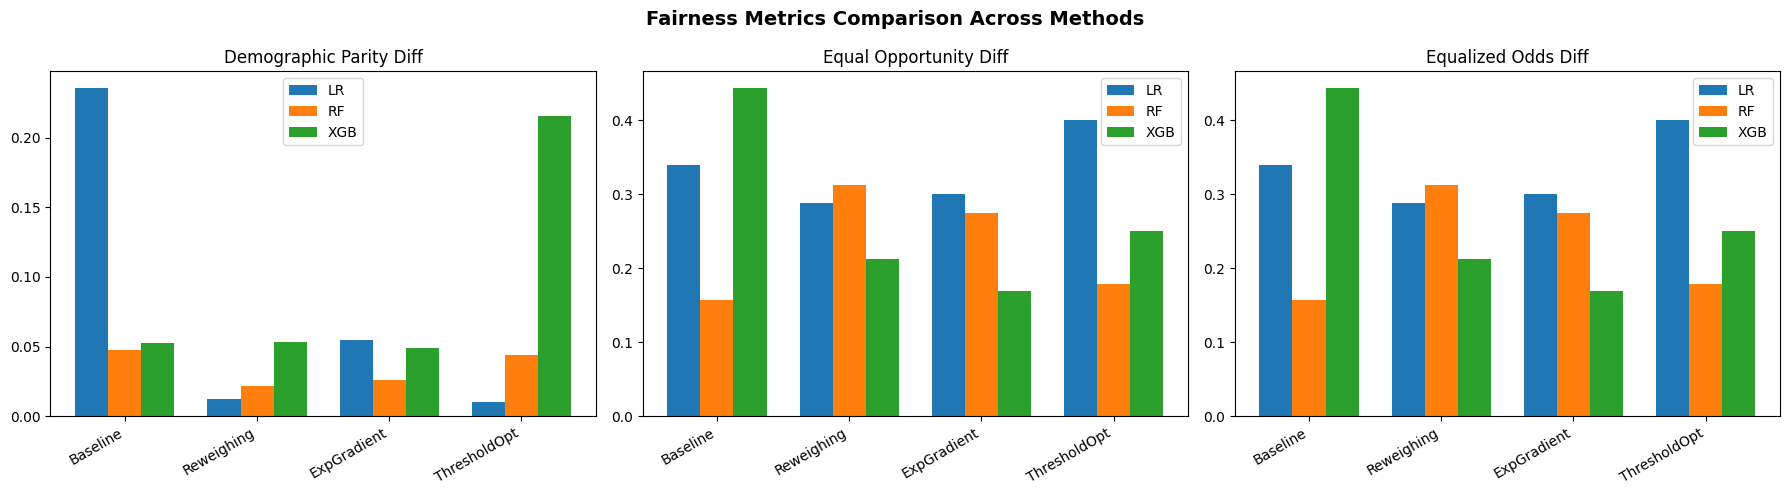

In [81]:
# Fairness Comparison Plot
methods = results_df["method"].unique()
models = ["LR", "RF", "XGB"]
fairness_metrics = ["dem_parity_diff", "equal_opp_diff", "equalized_odds"]
metric_labels = ["Demographic Parity Diff", "Equal Opportunity Diff", "Equalized Odds Diff"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Fairness Metrics Comparison Across Methods", fontweight="bold", fontsize=14)

for ax, metric, label in zip(axes, fairness_metrics, metric_labels):
    x = np.arange(len(methods))
    width = 0.25
    for i, model in enumerate(models):
        vals = []
        for method in methods:
            subset = results_df[(results_df["method"] == method) & (results_df["model"] == model)]
            vals.append(subset[metric].values[0] if len(subset) > 0 else 0)
        ax.bar(x + i * width, vals, width, label=model)
    ax.set_title(label)
    ax.set_xticks(x + width)
    ax.set_xticklabels(methods, rotation=30, ha="right")
    ax.legend()

plt.tight_layout()
plt.savefig("figures2/fairness_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

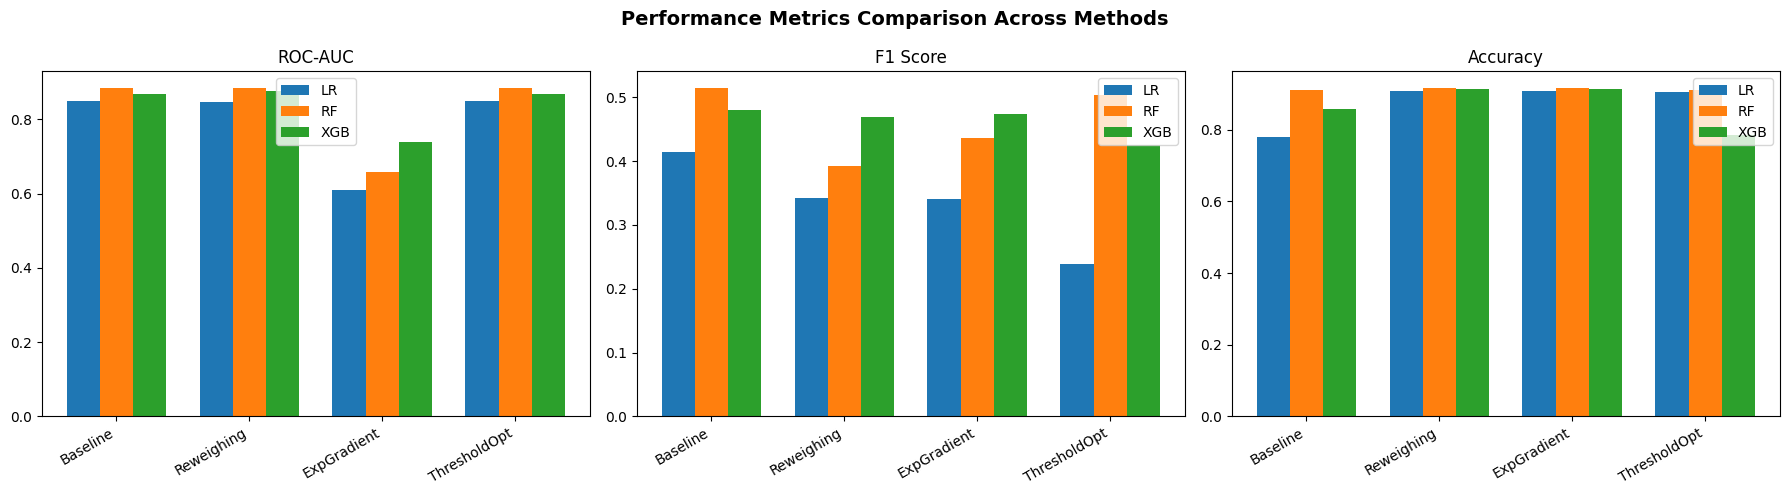

In [82]:
# Performance Comparison Plot
perf_metrics = ["roc_auc", "f1", "accuracy"]
perf_labels = ["ROC-AUC", "F1 Score", "Accuracy"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Performance Metrics Comparison Across Methods", fontweight="bold", fontsize=14)

for ax, metric, label in zip(axes, perf_metrics, perf_labels):
    x = np.arange(len(methods))
    width = 0.25
    for i, model in enumerate(models):
        vals = []
        for method in methods:
            subset = results_df[(results_df["method"] == method) & (results_df["model"] == model)]
            vals.append(subset[metric].values[0] if len(subset) > 0 else 0)
        ax.bar(x + i * width, vals, width, label=model)
    ax.set_title(label)
    ax.set_xticks(x + width)
    ax.set_xticklabels(methods, rotation=30, ha="right")
    ax.legend()

plt.tight_layout()
plt.savefig("figures2/performance_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

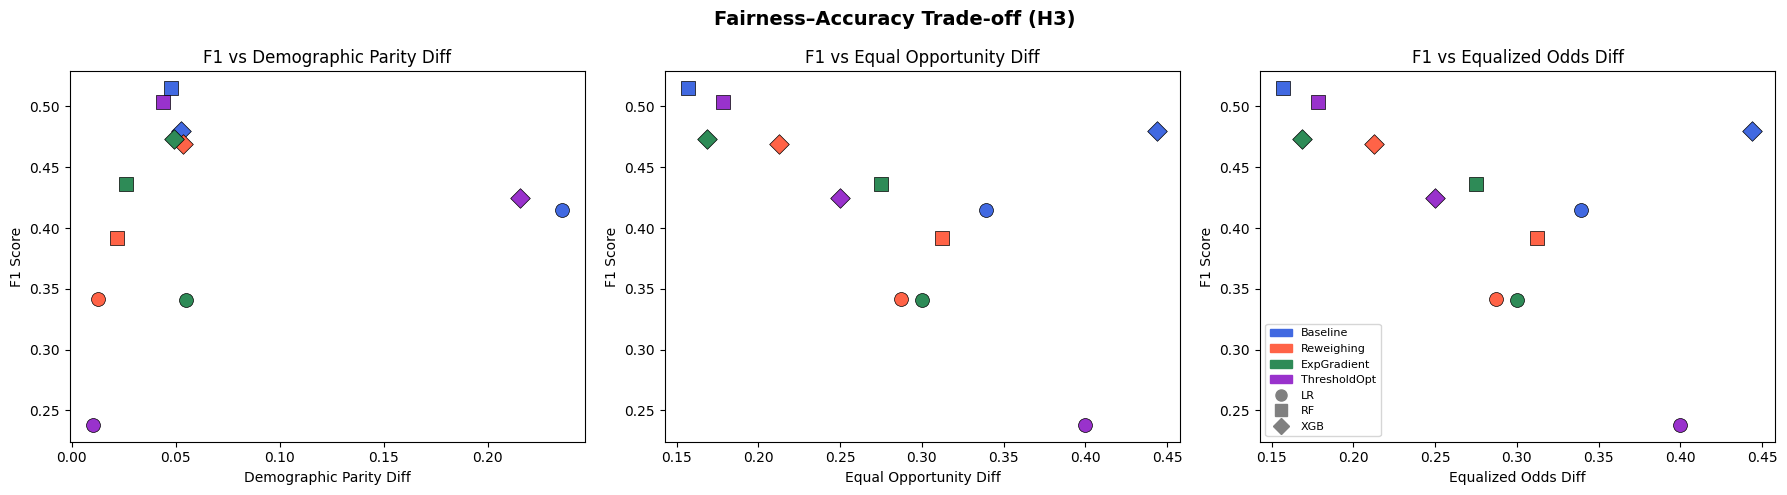

In [83]:
# Fairness-Accuracy Trade-off Plot
colors = {
    "Baseline": "royalblue",
    "Reweighing": "tomato",
    "ExpGradient": "seagreen",
    "ThresholdOpt": "darkorchid",
}
markers = {"LR": "o", "RF": "s", "XGB": "D"}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Fairness–Accuracy Trade-off (H3)", fontweight="bold", fontsize=14)

for ax, metric, label in zip(axes, fairness_metrics, metric_labels):
    for _, row in results_df.iterrows():
        ax.scatter(
            row[metric], row["f1"],
            color=colors.get(row["method"], "gray"),
            marker=markers.get(row["model"], "o"),
            s=100, edgecolors="black", linewidths=0.5
        )
    ax.set_xlabel(label)
    ax.set_ylabel("F1 Score")
    ax.set_title(f"F1 vs {label}")

# Legend
method_handles = [mpatches.Patch(color=c, label=m) for m, c in colors.items()]
model_handles = [mlines.Line2D([], [], color="gray", marker=mk, linestyle="None", markersize=8, label=m) for m, mk in markers.items()]
axes[-1].legend(handles=method_handles + model_handles, loc="best", fontsize=8)

plt.tight_layout()
plt.savefig("figures2/tradeoff_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Feature Importance Analysis

Using permutation importance to understand which features drive model predictions
and potentially contribute to bias.

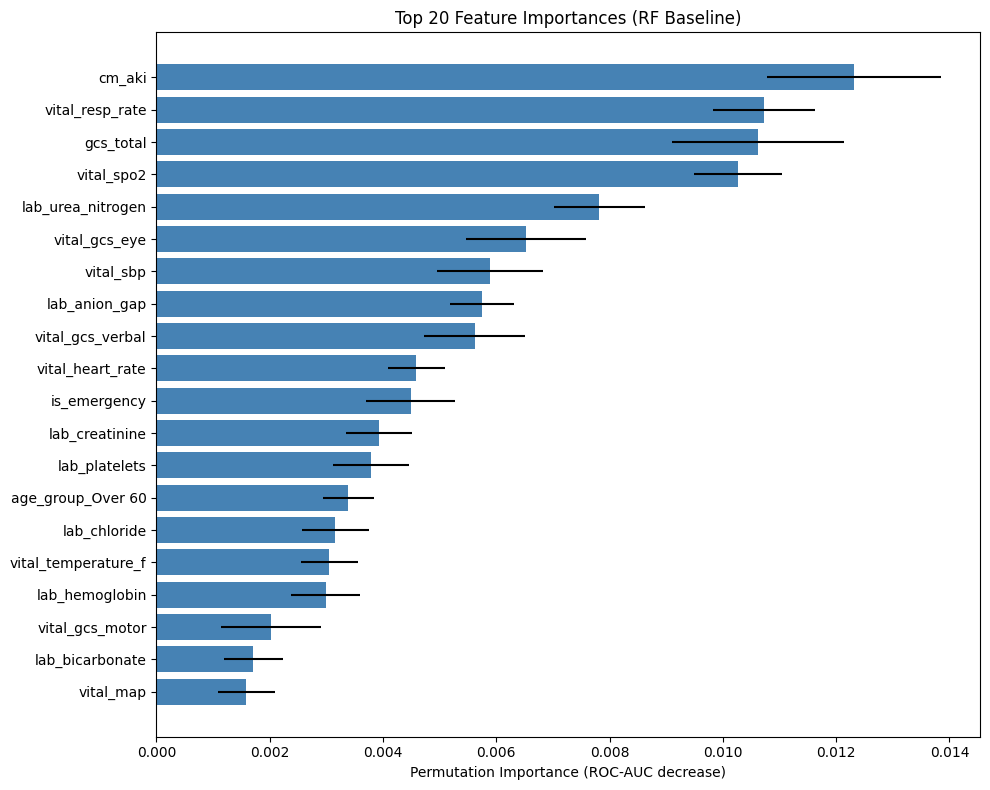


Importance of sensitive attribute features:
                   feature  importance_mean  importance_std
         age_group_Over 60     3.386688e-03    4.508122e-04
        age_group_Under 40     6.088784e-04    1.034160e-04
        age_group_40 to 60     3.884944e-04    1.658708e-04
          race_group_WHITE     1.502986e-04    1.233781e-04
                    gender     1.322617e-04    1.600772e-04
   insurance_group_private     7.189301e-05    1.136511e-04
          race_group_OTHER     4.972540e-05    4.710220e-05
     race_group_INDIGENOUS    -3.393334e-07    8.065442e-07
insurance_group_government    -2.964926e-05    1.177209e-04
          race_group_ASIAN    -3.683073e-05    4.859179e-05
          race_group_BLACK    -4.741859e-05    1.050138e-04


In [84]:
# Permutation importance for the RF baseline model
perm_imp = permutation_importance(
    rf_base, X_test, y_test,
    n_repeats=10, random_state=SEED, scoring="roc_auc"
)

imp_df = pd.DataFrame({
    "feature": feature_cols,
    "importance_mean": perm_imp.importances_mean,
    "importance_std": perm_imp.importances_std
}).sort_values("importance_mean", ascending=False)

# Plot top 20 features
fig, ax = plt.subplots(figsize=(10, 8))
top20 = imp_df.head(20)
ax.barh(range(len(top20)), top20["importance_mean"].values, xerr=top20["importance_std"].values, color="steelblue")
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20["feature"].values)
ax.invert_yaxis()
ax.set_xlabel("Permutation Importance (ROC-AUC decrease)")
ax.set_title("Top 20 Feature Importances (RF Baseline)")
plt.tight_layout()
plt.savefig("figures2/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

# Highlight sensitive attribute features
sens_features = [c for c in feature_cols if any(a in c for a in ["race_group", "gender", "insurance_group", "age_group"])]
print("\nImportance of sensitive attribute features:")
print(imp_df[imp_df["feature"].isin(sens_features)].to_string(index=False))

## 11. Calibration Analysis Across Groups

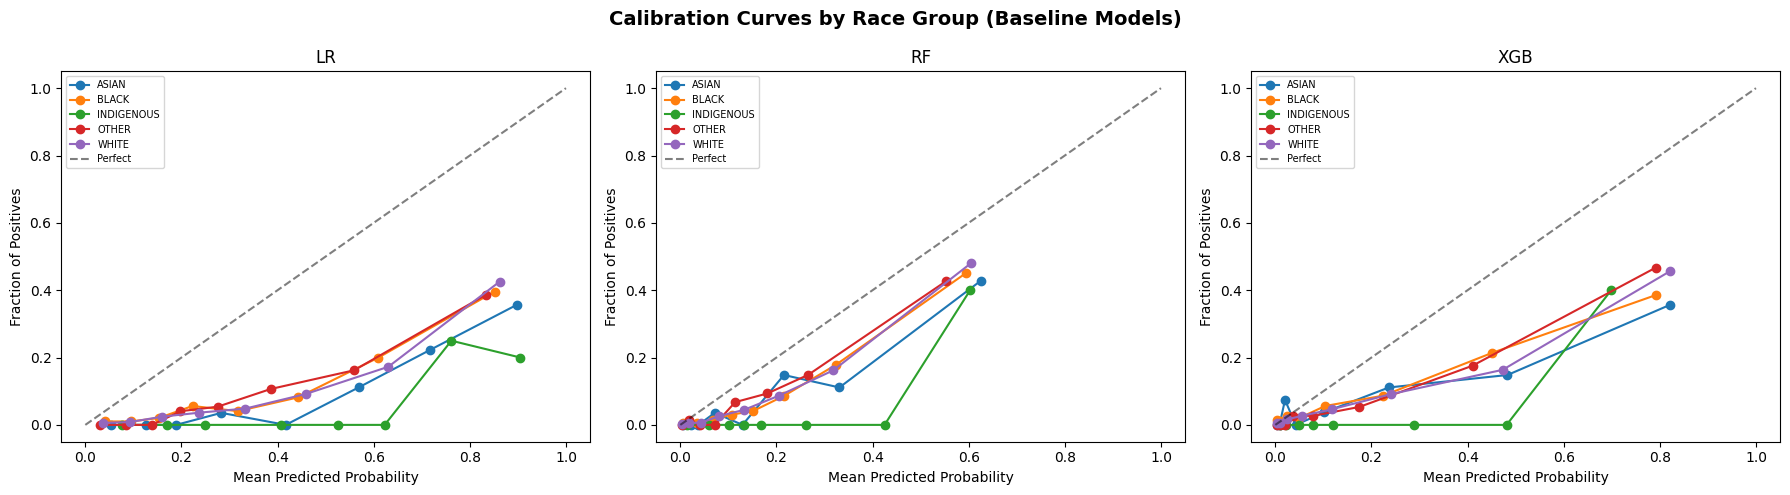

In [85]:
# Calibration curves per race group for each baseline model
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Calibration Curves by Race Group (Baseline Models)", fontweight="bold", fontsize=14)

for ax, (model_name, prob_col) in zip(axes, [("LR", "lr_prob"), ("RF", "rf_prob"), ("XGB", "xgb_prob")]):
    for group in attr_labels["race_group"]:
        gdf = test_df[test_df["race_group"] == group]
        if len(gdf) < 20:
            continue
        try:
            prob_true, prob_pred = calibration_curve(
                gdf["y_true"], gdf[prob_col], n_bins=8, strategy="quantile"
            )
            ax.plot(prob_pred, prob_true, marker="o", label=group, linewidth=1.5)
        except Exception:
            pass
    ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Perfect")
    ax.set_xlabel("Mean Predicted Probability")
    ax.set_ylabel("Fraction of Positives")
    ax.set_title(f"{model_name}")
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig("figures2/calibration_by_group.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Intersectional Bias Analysis

Intersectional bias = bias where an individual has two sensitive attributes (e.g. race and gender).

In [86]:
# Create intersectional groups: race × gender
test_df["race_gender"] = test_df["race_group"].astype(str) + "_" + test_df["gender"].astype(str)

print("Intersectional Analysis: Race × Gender (RF Baseline)")
print("="*80)

intersect_results = []
for group in sorted(test_df["race_gender"].unique()):
    gdf = test_df[test_df["race_gender"] == group]
    if len(gdf) < 10:
        continue
    y_true = gdf["y_true"].values
    y_pred = gdf["rf_pred"].values
    y_prob = gdf["rf_prob"].values
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    fpr_val = fp / (fp + tn) if (fp + tn) > 0 else 0
    fnr_val = fn / (fn + tp) if (fn + tp) > 0 else 0
    try:
        auc_val = roc_auc_score(y_true, y_prob)
    except Exception:
        auc_val = np.nan
    intersect_results.append({
        "group": group, "n": len(gdf), "mortality_rate": round(y_true.mean(), 4),
        "fpr": round(fpr_val, 4), "fnr": round(fnr_val, 4), "roc_auc": round(auc_val, 4) if not np.isnan(auc_val) else "N/A"
    })

intersect_df = pd.DataFrame(intersect_results)
print(intersect_df.to_string(index=False))
intersect_df.to_csv("results2/intersectional_analysis.csv", index=False)

Intersectional Analysis: Race × Gender (RF Baseline)
       group    n  mortality_rate    fpr    fnr  roc_auc
     ASIAN_0  113          0.0708 0.0857 0.7500   0.8060
     ASIAN_1  106          0.1132 0.0319 0.2500   0.9406
     BLACK_0  680          0.0824 0.0513 0.4821   0.8541
     BLACK_1  890          0.1169 0.0382 0.6250   0.8800
INDIGENOUS_0   14          0.0714 0.0769 1.0000   0.9231
INDIGENOUS_1   21          0.0476 0.0000 0.0000   1.0000
     OTHER_0  347          0.0980 0.0319 0.7059   0.8496
     OTHER_1  249          0.0884 0.0220 0.4545   0.9417
     WHITE_0 5948          0.0989 0.0394 0.5051   0.8913
     WHITE_1 4624          0.1051 0.0346 0.5556   0.8818


## 13. Cross-Validation Analysis

5-fold stratified cross-validation to assess robustness of fairness findings.

In [87]:
print("Stratified Cross-Validation (RF Baseline)")
print("="*80)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
    y_tr_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]
    s_val_cv = protected_df.iloc[val_idx][MAIN_ATTR]
    
    rf_cv = RandomForestClassifier(
        n_estimators=100, random_state=SEED,
        class_weight="balanced_subsample", min_samples_leaf=5
    )
    rf_cv.fit(X_tr_cv, y_tr_cv)
    y_pred_cv = rf_cv.predict(X_val_cv)
    y_prob_cv = rf_cv.predict_proba(X_val_cv)[:, 1]
    
    row = {"fold": fold + 1}
    row.update(get_standard_metrics(y_val_cv, y_pred_cv, y_prob_cv))
    row.update(get_fairness_metrics(y_val_cv, y_pred_cv, s_val_cv))
    cv_results.append(row)
    print(f"Fold {fold+1}: AUC={row['roc_auc']:.4f}, F1={row['f1']:.4f}, DPD={row['dem_parity_diff']:.4f}, EOD={row['equalized_odds']:.4f}")

cv_df = pd.DataFrame(cv_results)
print(f"\nMean ± Std:")
for col in ["roc_auc", "f1", "dem_parity_diff", "equal_opp_diff", "equalized_odds"]:
    print(f"  {col:25s}: {cv_df[col].mean():.4f} ± {cv_df[col].std():.4f}")

cv_df.to_csv("results2/cross_validation.csv", index=False)

Stratified Cross-Validation (RF Baseline)
Fold 1: AUC=0.8921, F1=0.5039, DPD=0.1154, EOD=0.5833
Fold 2: AUC=0.8800, F1=0.5059, DPD=0.0495, EOD=0.4667
Fold 3: AUC=0.8961, F1=0.5029, DPD=0.1231, EOD=0.5152
Fold 4: AUC=0.8834, F1=0.5051, DPD=0.0620, EOD=0.1763
Fold 5: AUC=0.8864, F1=0.5099, DPD=0.0333, EOD=0.5624

Mean ± Std:
  roc_auc                  : 0.8876 ± 0.0065
  f1                       : 0.5055 ± 0.0027
  dem_parity_diff          : 0.0767 ± 0.0403
  equal_opp_diff           : 0.4608 ± 0.1653
  equalized_odds           : 0.4608 ± 0.1653


## 14. Summary Table (Addressing H1, H2, H3)

In [88]:
print("\n" + "="*120)
print("SUMMARY: Hypothesis Testing")
print("="*120)

print("\nH1: Baseline models show statistically significant performance disparity")
print("-" * 80)
baseline = results_df[results_df["method"] == "Baseline"]
print(baseline[["model", "roc_auc", "f1", "dem_parity_diff", "equal_opp_diff", "equalized_odds", "fpr_gap", "fnr_gap"]].to_string(index=False))

print("\nH2: Mitigation techniques reduce disparity")
print("-" * 80)
for model in ["LR", "RF", "XGB"]:
    print(f"\n  {model}:")
    model_df = results_df[results_df["model"] == model][["method", "roc_auc", "f1", "dem_parity_diff", "equal_opp_diff", "equalized_odds"]]
    print(model_df.to_string(index=False))

print("\nH3: Fairness-accuracy trade-off")
print("-" * 80)
print("See trade-off plot in figures2/tradeoff_curve.png")
print(results_df[["method", "model", "roc_auc", "f1", "dem_parity_diff", "equalized_odds"]].to_string(index=False))


SUMMARY: Hypothesis Testing

H1: Baseline models show statistically significant performance disparity
--------------------------------------------------------------------------------
model  roc_auc     f1  dem_parity_diff  equal_opp_diff  equalized_odds  fpr_gap  fnr_gap
   LR   0.8499 0.4151           0.2357          0.3393          0.3393   0.2483   0.3393
   RF   0.8849 0.5150           0.0479          0.1571          0.1571   0.0325   0.1571
  XGB   0.8683 0.4801           0.0523          0.4437          0.4437   0.0589   0.4437

H2: Mitigation techniques reduce disparity
--------------------------------------------------------------------------------

  LR:
      method  roc_auc     f1  dem_parity_diff  equal_opp_diff  equalized_odds
    Baseline   0.8499 0.4151           0.2357          0.3393          0.3393
  Reweighing   0.8478 0.3419           0.0125          0.2875          0.2875
 ExpGradient   0.6107 0.3409           0.0548          0.3000          0.3000
ThresholdOpt   0